# Gravitational-Wave Detectability With a Neural Network

This notebook reuses the L20 detectability data and the GW theory point from L22: the class boundary is nonlinear, the parameter space is curved, and redshift is the dominant predictor. A small PyTorch MLP is a good fit for this tabular problem because it is flexible

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import torch
import torch.nn as nn
import torch.utils.data as torchdata
from sklearn.metrics import auc, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch device:", device)

Torch device: cpu


In [2]:
data_candidates = [
    Path("sample_2e7_design_precessing_higherordermodes_3detectors.h5"),
    Path("working") / "sample_2e7_design_precessing_higherordermodes_3detectors.h5",
]
DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find the GW sample HDF5 file in the workspace.")

features = [
    "mtot", "q", "chi1x", "chi1y", "chi1z", "chi2x", "chi2y", "chi2z",
    "ra", "dec", "iota", "psi", "z",
]

N_SUB = 50000
with h5py.File(DATA_PATH, "r") as handle:
    X_raw = np.column_stack([handle[feat][:N_SUB] for feat in features])
    y_det = handle["det"][:N_SUB].astype(np.int64)
    y_snr = handle["snr"][:N_SUB]

X_df = pd.DataFrame(X_raw, columns=features)
X_train_raw, X_val_raw, y_train, y_val, y_train_snr, y_val_snr = train_test_split(
    X_df, y_det, y_snr, test_size=0.3, stratify=y_det, random_state=42
)

print(f"Loaded {len(X_df):,} sources from {DATA_PATH.name}")
print("Detection rate in sample:", round(y_det.mean(), 4))
print("Redshift summary:")
print(X_df["z"].describe())

Loaded 50,000 sources from sample_2e7_design_precessing_higherordermodes_3detectors.h5
Detection rate in sample: 0.1429
Redshift summary:
count    50000.000000
mean         1.998295
std          1.152190
min          0.000119
25%          1.003890
50%          1.998753
75%          2.991178
max          3.999969
Name: z, dtype: float64


Best validation AUC: 0.9949 at epoch 78
Validation confusion matrix:
[[12253   604]
 [   34  2109]]
Validation completeness: 0.9841
Validation contamination: 0.2226


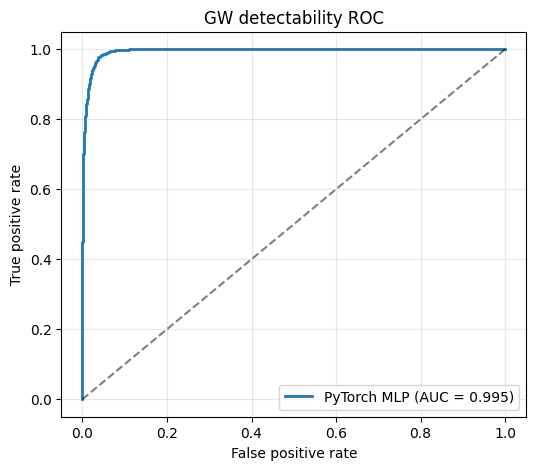

Validation AUC with shuffled z: 0.5327
AUC drop from shuffling z: 0.4622


In [ ]:
# Standardize the tabular inputs because the physical features live on very different scales.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)

# Move the standardized arrays into PyTorch tensors on the selected device.
X_torch_train = torch.tensor(X_train, dtype=torch.float32, device=device)
X_torch_val = torch.tensor(X_val, dtype=torch.float32, device=device)
y_torch_train = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32, device=device)
y_torch_val = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32, device=device)

# The class is imbalanced, so we up-weight the positive class in the binary loss.
pos_count = y_train.sum()
neg_count = len(y_train) - pos_count
pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32, device=device)

# Simple MLP for tabular GW detectability.
# Input layer: the 13 GW parameters from L20.
# Hidden layers: ReLU blocks that can learn the curved decision surface.
# Dropout: regularization to reduce overfitting.
# Output layer: one logit for binary classification.
class GWDetectabilityNet(nn.Module):
    def __init__(self, input_dim: int, hidden_layers=(64, 32), dropout=0.25):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Train one model with early stopping on validation AUC.
def fit_model(X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, hidden_layers=(64, 32), dropout=0.25, lr=1e-3, batch_size=256, max_epochs=80, patience=10):
    model = GWDetectabilityNet(X_train_tensor.shape[1], hidden_layers=hidden_layers, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    train_loader = torchdata.DataLoader(
        torchdata.TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=batch_size,
        shuffle=True,
    )

    best_state = None
    best_auc = -np.inf
    best_epoch = 0
    stalled_epochs = 0

    for epoch in range(max_epochs):
        # Training phase: update weights on mini-batches.
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # Validation phase: evaluate the full held-out split without gradients.
        model.eval()
        with torch.no_grad():
            val_prob = torch.sigmoid(model(X_val_tensor)).squeeze(1).cpu().numpy()
        val_auc = roc_auc_score(y_val_tensor.squeeze(1).cpu().numpy(), val_prob)

        # Keep the checkpoint that best separates detectable from non-detectable events.
        if val_auc > best_auc + 1e-4:
            best_auc = val_auc
            best_epoch = epoch + 1
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            stalled_epochs = 0
        else:
            stalled_epochs += 1
            if stalled_epochs >= patience:
                break

    # Restore the best epoch before returning the final tuned model.
    model.load_state_dict(best_state)
    return model, best_auc, best_epoch


# Convert logits to probabilities for evaluation and plotting.
def predict_proba(model, X_tensor):
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(X_tensor)).squeeze(1).cpu().numpy()


# Fit the network on the training split and score it on validation.
model, best_val_auc, best_epoch = fit_model(X_torch_train, y_torch_train, X_torch_val, y_torch_val)
y_val_prob = predict_proba(model, X_torch_val)
y_val_pred = (y_val_prob >= 0.5).astype(int)
fpr, tpr, _ = roc_curve(y_val, y_val_prob)

# Compute simple classification diagnostics to complement the ROC curve.
tp = np.sum((y_val == 1) & (y_val_pred == 1))
fp = np.sum((y_val == 0) & (y_val_pred == 1))
fn = np.sum((y_val == 1) & (y_val_pred == 0))
completeness = tp / max(tp + fn, 1)
contamination = fp / max(tp + fp, 1)

print(f"Best validation AUC: {best_val_auc:.4f} at epoch {best_epoch}")
print("Validation confusion matrix:")
print(confusion_matrix(y_val, y_val_pred))
print(f"Validation completeness: {completeness:.4f}")
print(f"Validation contamination: {contamination:.4f}")

# ROC curve for the detectability classifier.
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"PyTorch MLP (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("GW detectability ROC")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Redshift ablation test: shuffle z only in the validation set and re-score.
# If z is physically important, the AUC should drop noticeably.
X_val_noz = X_val_raw.copy()
X_val_noz["z"] = np.random.default_rng(42).permutation(X_val_noz["z"].values)
X_val_noz = scaler.transform(X_val_noz)
X_torch_val_noz = torch.tensor(X_val_noz, dtype=torch.float32, device=device)
y_val_prob_noz = predict_proba(model, X_torch_val_noz)
auc_noz = roc_auc_score(y_val, y_val_prob_noz)
print(f"Validation AUC with shuffled z: {auc_noz:.4f}")
print(f"AUC drop from shuffling z: {best_val_auc - auc_noz:.4f}")